Para ejercitarte y afianzar lo aprendido sobre **Transfer Learning y Fine-tuning**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import os
import cv2 # Ideal para procesamiento rápido de imágenes
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D

## Apple 360

En este conjunto de ejercicios vas a montar un clasificador de manzanas mediante un dataset de imágenes. El dataset se compone de 13 tipos diferentes con aproximadamente unas 200 imágenes por cada tipo. Tendrás que montar un modelo de deep learning que utilice **transfer learning**. Se sugiere empezar con una red ResNet50 con imagenet.

El dataset original proviene del [concurso de Kaggle Fruits 360](https://www.kaggle.com/moltean/fruits), pero adaptado para la clasificación de una menor cantidad de casos (sólo las manzanas).


### Ejercicio 1

Crea los juegos de X,y para train y test a partir de los datos teninendo en cuenta su distribución, para ello tendrás que explorar las estructura. Crea un juego Train,test para resolución 32x32 y un juego de test adicional para 224x224. Es decir tendras que tener un X_train, X_test para 32x32 y un X_test adicional a 224x224

In [2]:
def cargar_datos_imagen(ruta_base, resolucion):
    """
    Lee las imágenes de la ruta indicada, las redimensiona y extrae la etiqueta (nombre de la carpeta).
    """
    X, y = [], []
    
    # Iteramos sobre cada subcarpeta (cada tipo de manzana)
    for clase in os.listdir(ruta_base):
        ruta_clase = os.path.join(ruta_base, clase)
        
        if os.path.isdir(ruta_clase):
            for archivo in os.listdir(ruta_clase):
                ruta_img = os.path.join(ruta_clase, archivo)
                img = cv2.imread(ruta_img)
                
                if img is not None:
                    # Redimensionamos a la resolución pasada por parámetro
                    img = cv2.resize(img, (resolucion, resolucion))
                    # OpenCV lee en BGR por defecto, lo pasamos a RGB para que se vea natural
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    
                    X.append(img)
                    y.append(clase)
                    
    return np.array(X), np.array(y)

In [5]:
# Definimos las rutas (ajusta los strings si el directorio se llama distinto)
ruta_train = 'data/apples/Train' 
ruta_test = 'data/apples/Test'

# Generamos los arrays para 32x32
X_train_32, y_train_32 = cargar_datos_imagen(ruta_train, 32)
X_test_32, y_test_32 = cargar_datos_imagen(ruta_test, 32) 

# Generamos el array de test adicional para 224x224
X_test_224, y_test_224 = cargar_datos_imagen(ruta_test, 224)

print(f"Dimensiones X_train (32x32): {X_train_32.shape}")
print(f"Dimensiones X_test (224x224): {X_test_224.shape}")

Dimensiones X_train (32x32): (6404, 32, 32, 3)
Dimensiones X_test (224x224): (2134, 224, 224, 3)


**NOTA:** A partir de aquí emplea siempre el X_train, X_test de 32x32 salvo en el ejercicio que se te diga lo contrario.

### Ejercicio 2

Haz una visualización de algunos de los datos. Crea una función que te ayude con ello.

In [6]:
def visualizar_muestra(X, y, num_imagenes=5):
    """
    Muestra una cuadrícula con imágenes aleatorias y su etiqueta correspondiente.
    """
    plt.figure(figsize=(15, 5))
    
    for i in range(num_imagenes):
        # Escogemos un índice aleatorio
        idx = np.random.randint(0, len(X))
        
        # Subplot de 1 fila, "num_imagenes" columnas
        plt.subplot(1, num_imagenes, i + 1)
        plt.imshow(X[idx])
        plt.title(f"Clase: {y[idx]}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

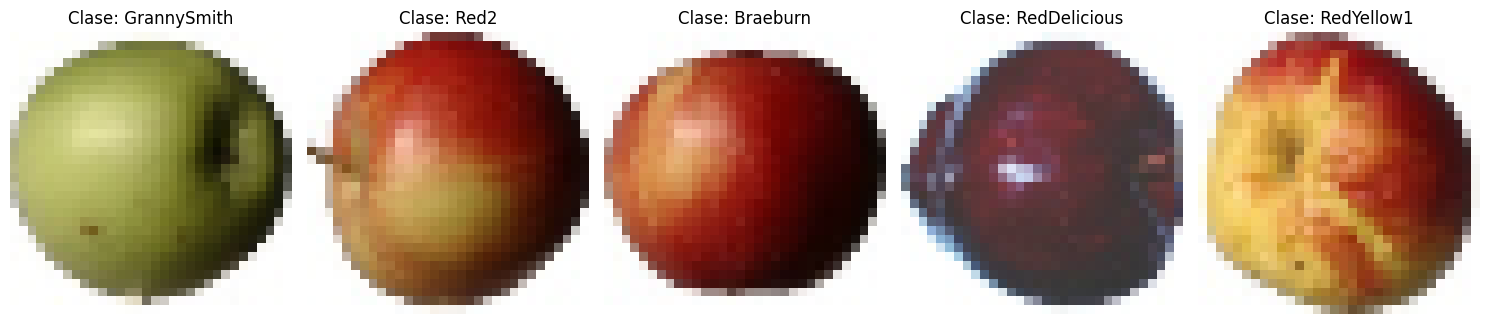

In [13]:
# Echamos un vistazo a 5 imágenes del conjunto de entrenamiento
visualizar_muestra(X_train_32, y_train_32, num_imagenes=5)

### Ejercicio 3

Completa el miniEDA habitual con imágenes y escoge una métrica para el modelo.

--- MiniEDA: Distribución de Clases ---
Tipo de manzana: Braeburn -> 492 imágenes
Tipo de manzana: CrimsonSnow -> 444 imágenes
Tipo de manzana: Golden1 -> 480 imágenes
Tipo de manzana: Golden2 -> 492 imágenes
Tipo de manzana: Golden3 -> 481 imágenes
Tipo de manzana: GrannySmith -> 492 imágenes
Tipo de manzana: PinkLady -> 456 imágenes
Tipo de manzana: Red1 -> 492 imágenes
Tipo de manzana: Red2 -> 492 imágenes
Tipo de manzana: Red3 -> 429 imágenes
Tipo de manzana: RedDelicious -> 490 imágenes
Tipo de manzana: RedYellow1 -> 492 imágenes
Tipo de manzana: RedYellow2 -> 672 imágenes

--- MiniEDA: Valores de los píxeles ---
Valor mínimo del píxel: 0
Valor máximo del píxel: 255


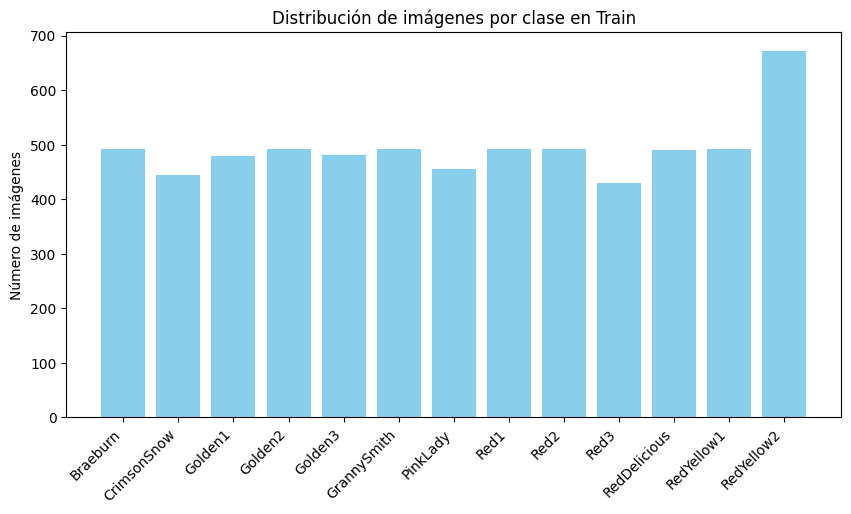

In [14]:
# Comprobamos la distribución de clases en el conjunto de entrenamiento
clases, conteos = np.unique(y_train_32, return_counts=True)

print("--- MiniEDA: Distribución de Clases ---")
for clase, conteo in zip(clases, conteos):
    print(f"Tipo de manzana: {clase} -> {conteo} imágenes")

# Comprobamos el rango de los píxeles (debería ser de 0 a 255)
print("\n--- MiniEDA: Valores de los píxeles ---")
print(f"Valor mínimo del píxel: {X_train_32.min()}")
print(f"Valor máximo del píxel: {X_train_32.max()}")

# visualizamos la distribución en un gráfico de barras:
plt.figure(figsize=(10, 5))
plt.bar(clases, conteos, color='skyblue')
plt.title('Distribución de imágenes por clase en Train')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Número de imágenes')
plt.show()

### Ejercicio 4 

Termina de transformar los datos si crees que es conveniente y aunque el entrenamiento de modelos de keras ya tiene un shuffling interno, haz un "barajado" del X_train (del X_test no es necesario) para facilitar la convergencia inicial del modelo. Utiliza la función shuffle de sklearn y asigna la salida a un X_train distinto (es decir no machaques el inicial)

In [15]:
# 1. Normalización de las imágenes (escala 0 a 1)
# Lo aplicamos también al test, porque el modelo debe predecir en la misma escala en la que entrena
X_train_norm = X_train_32.astype('float32') / 255.0
X_test_norm = X_test_32.astype('float32') / 255.0

# 2. Barajado (Shuffle) del conjunto de entrenamiento
# Usamos variables nuevas (X_train_shuffled, y_train_shuffled) para no machacar las iniciales
X_train_shuffled, y_train_shuffled = shuffle(X_train_norm, y_train_32, random_state=42)

print("Datos normalizados y barajados correctamente.")
print(f"Nuevo rango de píxeles: {X_train_shuffled.min()} a {X_train_shuffled.max()}")

Datos normalizados y barajados correctamente.
Nuevo rango de píxeles: 0.0 a 1.0


### Ejercicio 5

Sklearn permite trabajar con etiquetas textuales pero keras no. Transforma las etiquetas a numéricas, creando dos diccionarios uno que permita traducir de etiqueta a clase numérica y otro que permita la transformación inversa.

In [16]:
# Como Keras no traga con etiquetas de texto, necesitamos pasarlas a números. 
# Para hacerlo bien y no perder la referencia de qué número corresponde a qué tipo de manzana, nos piden crear dos diccionarios: 
# uno para pasar de texto a número y otro para hacer el camino inverso.

# Sacamos la lista de clases únicas (los 13 tipos de manzanas)
clases_unicas = np.unique(y_train_32)

# 1. Diccionario: Texto -> Número
label_to_num = {etiqueta: numero for numero, etiqueta in enumerate(clases_unicas)}

# 2. Diccionario: Número -> Texto
num_to_label = {numero: etiqueta for numero, etiqueta in enumerate(clases_unicas)}

# Transformamos los arrays de etiquetas usando el diccionario
# Ojo: utilizamos y_train_shuffled si seguimos el hilo del ejercicio anterior
y_train_num = np.array([label_to_num[etiqueta] for etiqueta in y_train_shuffled])
y_test_num = np.array([label_to_num[etiqueta] for etiqueta in y_test_32])

print("Ejemplo del diccionario (Texto a Número):")
print(label_to_num)

Ejemplo del diccionario (Texto a Número):
{np.str_('Braeburn'): 0, np.str_('CrimsonSnow'): 1, np.str_('Golden1'): 2, np.str_('Golden2'): 3, np.str_('Golden3'): 4, np.str_('GrannySmith'): 5, np.str_('PinkLady'): 6, np.str_('Red1'): 7, np.str_('Red2'): 8, np.str_('Red3'): 9, np.str_('RedDelicious'): 10, np.str_('RedYellow1'): 11, np.str_('RedYellow2'): 12}


### Ejercicio 6: Zero Shot Learning

Descar el modelo ResNet50 preparado ya para poder usarlo directamente a la Zero Shot Learning. Pruébalo contra el test (aquí no valen nuestras categorías serán las que proporcione ResNet ojo). Prueba una selección aleatoria de imágenes del test y compara las etiquetas de ResNet con la que tiene. ¿Nos sirve este clasificador así tal cual?

In [17]:
# l objetivo del Zero Shot Learning es descargar una red ya preentrenada (en este caso ResNet50) 
# y usarla directamente, sin tocarle los pesos ni entrenarla con nuestros datos.

# Nos piden probar el modelo contra el conjunto de test y comparar las etiquetas que predice ResNet con las reales. 
# Hay que tener en cuenta un detalle vital: la ResNet50 original entrenada con ImageNet espera imágenes de 224x224, 
# por lo que aquí debemos usar el conjunto X_test_224 que preparamos en el primer ejercicio, y no el de 32x32. 
# Además, hay que usar la función preprocess_input específica de ResNet50 para que los colores 
# y valores de los píxeles estén en el formato exacto que espera la red.

from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

# Descargamos el modelo completo (incluyendo la "cabeza" de clasificación)
modelo_zero_shot = ResNet50(weights='imagenet')

# Seleccionamos unas cuantas imágenes aleatorias del test de 224x224
indices_aleatorios = np.random.choice(len(X_test_224), 5, replace=False)
imagenes_muestra = X_test_224[indices_aleatorios]
etiquetas_reales = y_test_224[indices_aleatorios]

# Preprocesamos las imágenes según los estándares de ResNet50
# Ojo: convertimos a float y aplicamos preprocess_input
imagenes_preprocesadas = preprocess_input(imagenes_muestra.astype(np.float32))

# Hacemos la predicción
predicciones = modelo_zero_shot.predict(imagenes_preprocesadas)
predicciones_decodificadas = decode_predictions(predicciones, top=1) # Nos quedamos con la top 1


102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


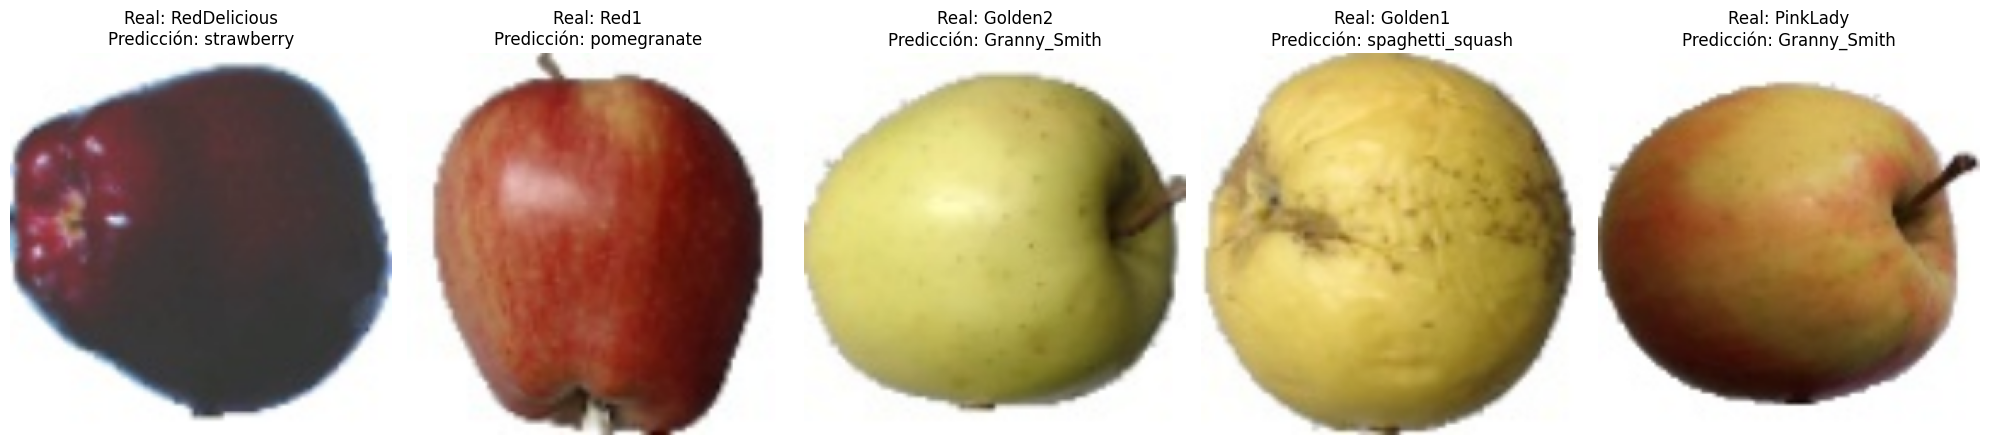

In [20]:
# Mostramos los resultados
plt.figure(figsize=(20, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    # Volvemos a mostrar la imagen original (sin el preprocesado raro)
    plt.imshow(imagenes_muestra[i])
    
    etiqueta_real = etiquetas_reales[i]
    # Decode predictions devuelve una lista de listas: [ID_clase, Nombre_clase, Probabilidad]
    etiqueta_predicha = predicciones_decodificadas[i][0][1] 
    
    plt.title(f"Real: {etiqueta_real}\nPredicción: {etiqueta_predicha}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Transfer Learning

### Ejercicio 7:

Carga la ResNet50 sin cabezas, crea un modelo con el anterior y una cabeza con dos capas densas, una oculta de 300 unidades (con activación "relu") y otra de salida con las unidades que crees necesarias y activación la que consideres. Congela las capas del modelo base (la ResNet50). Define también los hiperparámetros necesarios para compilar y compila el modelo y muestra un summary del mismo.

In [ ]:
# El objetivo aquí es cargar la red ResNet50 quitándole su capa de salida original (las "cabezas"), 
# ya que estaba diseñada para mil clases de ImageNet. 
# En su lugar, vamos a acoplarle nuestras propias capas: una densa oculta de 300 neuronas con activación ReLU, 
# y una de salida con 13 neuronas (una por cada tipo de manzana) y activación Softmax. 
# Además, es fundamental congelar los pesos del modelo base para que no se modifiquen durante esta primera fase de entrenamiento.
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Cargamos el modelo base sin la cabeza clasificadora y adaptado a nuestra resolución
modelo_base = ResNet50(
    weights='imagenet', 
    include_top=False, 
    input_shape=(32, 32, 3))

# Congelamos las capas de la ResNet50 para que no se entrenen ahora
modelo_base.trainable = False

# Montamos nuestro modelo secuencial
modelo_tl = Sequential([
    modelo_base,
    GlobalAveragePooling2D(), # Aplana los mapas de características a un vector 1D
    Dense(300, activation='relu'),
    Dense(13, activation='softmax') # 13 clases de manzanas
])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [22]:
# Compilamos el modelo. Usamos sparse_categorical_crossentropy porque nuestras etiquetas numéricas son enteros, no one-hot arrays
modelo_tl.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])

# Mostramos el resumen
modelo_tl.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       614,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │         3,913 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,206,325 (92.34 MB)

 Trainable params: 618,613 (2.36 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Ejercicio 8

Entrena el modelo con nuestros datos de train y muestra la evolución del entrenamiento. Emplea un callback de Earlystopping con patience a 5. Termina de escoger el batch_size y el número de épocas.

In [23]:
# Toca entrenar el modelo con nuestros datos de train. 
# Para evitar el sobreajuste (overfitting) y no gastar recursos a lo tonto, 
# nos piden usar un callback de EarlyStopping con una paciencia de 5 épocas. 
# Esto significa que si la métrica de validación no mejora durante 5 épocas seguidas, el entrenamiento se corta automáticamente. 
# Le podemos poner 50 épocas de máximo y un batch_size estándar de 32.

from tensorflow.keras.callbacks import EarlyStopping

# Configuramos el EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True # Nos quedamos con los pesos de la mejor época, no de la última
)

# Entrenamos el modelo. Separamos un 20% del conjunto de entrenamiento para validación interna
history = modelo_tl.fit(
    X_train_shuffled, 
    y_train_num,
    epochs=50, 
    batch_size=32,
    validation_split=0.2, 
    callbacks=[early_stopping]
)

Epoch 1/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.3178 - loss: 2.0855 - val_accuracy: 0.4395 - val_loss: 1.5772
Epoch 2/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.4976 - loss: 1.4250 - val_accuracy: 0.5488 - val_loss: 1.2403
Epoch 3/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.6112 - loss: 1.1237 - val_accuracy: 0.5753 - val_loss: 1.1166
Epoch 4/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.6604 - loss: 0.9611 - val_accuracy: 0.5972 - val_loss: 1.0448
Epoch 5/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.7006 - loss: 0.8378 - val_accuracy: 0.7627 - val_loss: 0.7518
Epoch 6/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.7361 - loss: 0.7443 - val_accuracy: 0.6550 - val_loss: 0.8147
Epoch 7/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.7798 - loss: 0.6521 - val_accuracy: 0.8041 - val_loss: 0.5852
Epoch 8/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8112 - loss: 0.5700 - val_acc

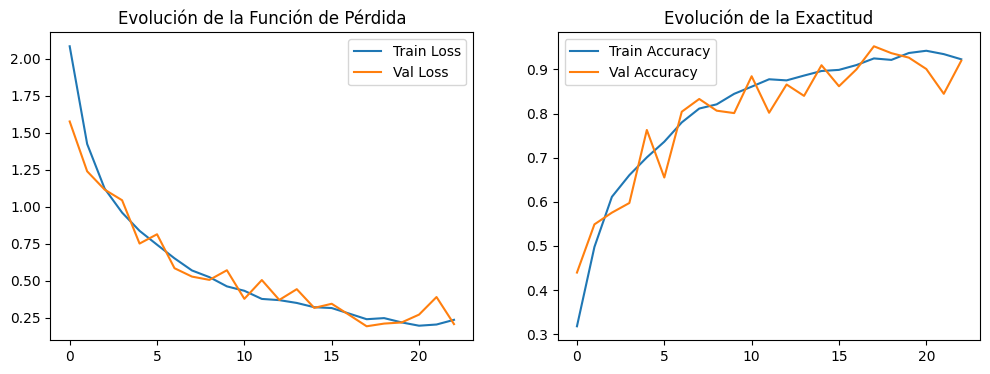

In [24]:
# Visualizamos la evolución del entrenamiento
plt.figure(figsize=(12, 4))

# Gráfica de la pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Evolución de la Función de Pérdida')
plt.legend()

# Gráfica de la exactitud (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Evolución de la Exactitud')
plt.legend()

plt.show()

### Ejercicio 9

Evalua el modelo contra test y haz un pequeño análisis de las diferencias. Haz un clasification report y muestra la matriz de confusion. Haz un pequeño análisis de errores.

In [25]:
# Una vez entrenado, hay que poner el modelo a prueba contra el conjunto de test para ver cómo se comporta con datos que no ha visto nunca. 
# Sacaremos el informe de clasificación y pintaremos la matriz de confusión para hacer un pequeño análisis 
# de los errores y ver qué tipos de manzanas confunde entre sí.

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Evaluamos el modelo contra el conjunto de test
loss, accuracy = modelo_tl.evaluate(X_test_norm, y_test_num, verbose=0)
print(f"Exactitud en Test: {accuracy * 100:.2f}%\n")

# Hacemos las predicciones
predicciones_prob = modelo_tl.predict(X_test_norm)
# Nos quedamos con la clase que tenga mayor probabilidad
predicciones_clases = np.argmax(predicciones_prob, axis=1)



Exactitud en Test: 76.80%

67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step


--- Classification Report ---
              precision    recall  f1-score   support

    Braeburn       0.84      0.66      0.74       164
 CrimsonSnow       0.75      0.38      0.50       148
     Golden1       0.55      0.88      0.68       160
     Golden2       0.91      0.91      0.91       164
     Golden3       0.60      0.39      0.47       161
 GrannySmith       1.00      0.66      0.80       164
    PinkLady       0.58      1.00      0.74       152
        Red1       0.83      0.84      0.83       164
        Red2       0.57      0.77      0.66       164
        Red3       0.94      0.63      0.76       144
RedDelicious       1.00      0.84      0.92       166
  RedYellow1       0.76      0.90      0.82       164
  RedYellow2       1.00      0.99      1.00       219

    accuracy                           0.77      2134
   macro avg       0.79      0.76      0.76      2134
weighted avg       0.80      0.77      0.76      2134



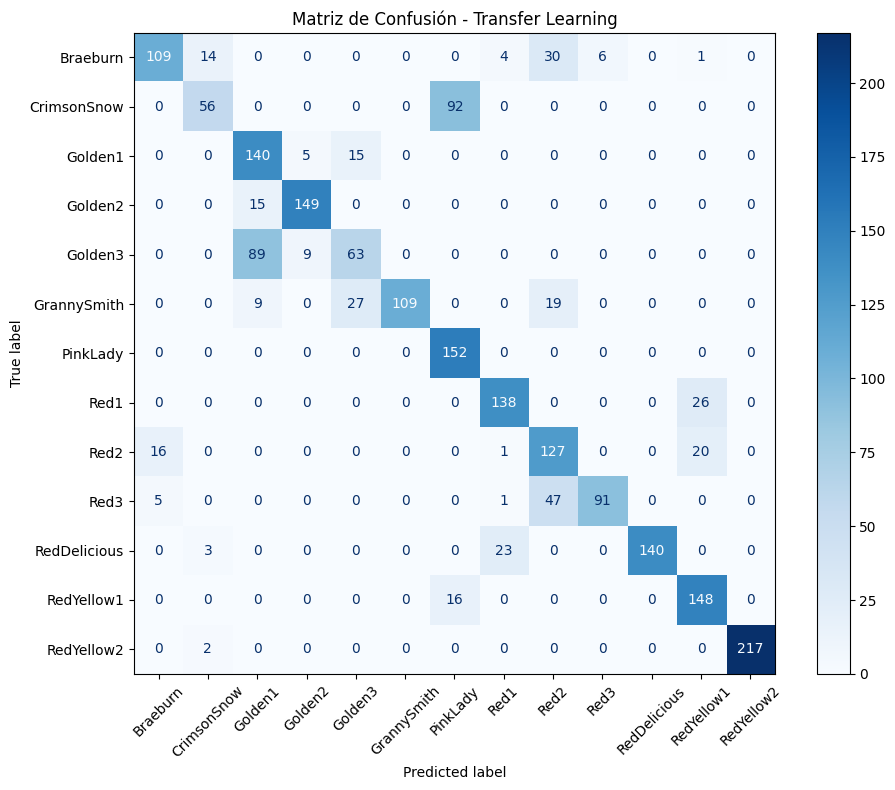

In [26]:
# Mostramos el Classification Report
nombres_clases = [num_to_label[i] for i in range(13)]
print("--- Classification Report ---")
print(classification_report(y_test_num, predicciones_clases, target_names=nombres_clases))

# Calculamos y mostramos la matriz de confusión
matriz_conf = confusion_matrix(y_test_num, predicciones_clases)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_conf, display_labels=nombres_clases)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, ax=plt.gca())
plt.title('Matriz de Confusión - Transfer Learning')
plt.tight_layout()
plt.show()

## Fine Tuning

### Ejercicio 10

Vuelve a descargar el modelo ResNet50 pero sin pesos entrenados, ni cabeza, crea el mismo modelo personalizado que en el ejercicio 7, compila y muestra el summary.

In [ ]:
# En esta fase se nos pide instanciar de nuevo la arquitectura ResNet50 sin su cabeza clasificadora, 
# pero con un cambio drástico: esta vez no cargamos los pesos entrenados de ImageNet. 
# Luego, hay que replicar la estructura de capas densas del ejercicio 7, compilar el modelo y sacar el resumen por pantalla.

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Cargamos la arquitectura ResNet50 SIN pesos preentrenados (weights=None) y sin cabeza
modelo_base_ft = ResNet50(
    weights=None, 
    include_top=False, 
    input_shape=(32, 32, 3))

# Montamos exactamente el mismo modelo secuencial que en el Ejercicio 7
modelo_ft = Sequential([
    modelo_base_ft,
    GlobalAveragePooling2D(),
    Dense(300, activation='relu'),
    Dense(13, activation='softmax')
])

# Compilamos el modelo con los mismos parámetros
modelo_ft.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])

# Mostramos el resumen
modelo_ft.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 300)            │       614,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 13)             │         3,913 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,206,325 (92.34 MB)

 Trainable params: 24,153,205 (92.14 MB)

 Non-trainable params: 53,120 (207.50 KB)

### Ejercicio 11
Entrena con batch_size a 64 y 60 épocas, con un EarlyStopping de patience a 10 (ahora el entrenamiento es sensiblemente más largo, así que tómate un descanso). Muestra la evolución y da una posible justificación a emplear tantas épocas de partida.

In [28]:
# Ahora toca entrenar este nuevo modelo configurando el batch_size a 64, ampliando a 60 épocas y subiendo la paciencia del EarlyStopping a 10. 
# También se nos pide mostrar la evolución y justificar por qué necesitamos tantas épocas de partida.

from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Configuramos el nuevo EarlyStopping con patience a 10
early_stopping_ft = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

# Arrancamos el entrenamiento (esto va a tardar un rato)
history_ft = modelo_ft.fit(
    X_train_shuffled, 
    y_train_num,
    epochs=60, 
    batch_size=64,
    validation_split=0.2, 
    callbacks=[early_stopping_ft]
)

Epoch 1/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 49s 386ms/step - accuracy: 0.8282 - loss: 0.7451 - val_accuracy: 0.0695 - val_loss: 3.1221
Epoch 2/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 31s 377ms/step - accuracy: 0.9096 - loss: 0.2991 - val_accuracy: 0.0827 - val_loss: 3.0264
Epoch 3/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 31s 387ms/step - accuracy: 0.9758 - loss: 0.0743 - val_accuracy: 0.0695 - val_loss: 3.7765
Epoch 4/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 30s 374ms/step - accuracy: 0.9932 - loss: 0.0224 - val_accuracy: 0.1405 - val_loss: 5.4510
Epoch 5/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 30s 377ms/step - accuracy: 0.9471 - loss: 0.1818 - val_accuracy: 0.2311 - val_loss: 6.1733
Epoch 6/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 30s 373ms/step - accuracy: 0.9639 - loss: 0.1260 - val_accuracy: 0.4223 - val_loss: 5.0540
Epoch 7/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 30s 375ms/step - accuracy: 0.9955 - loss: 0.0181 - val_accuracy: 0.9204 - val_loss: 0.2127
Epoch 8/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 31s 383ms/step - accuracy: 0.9676 - loss: 0.1256 - val_accu

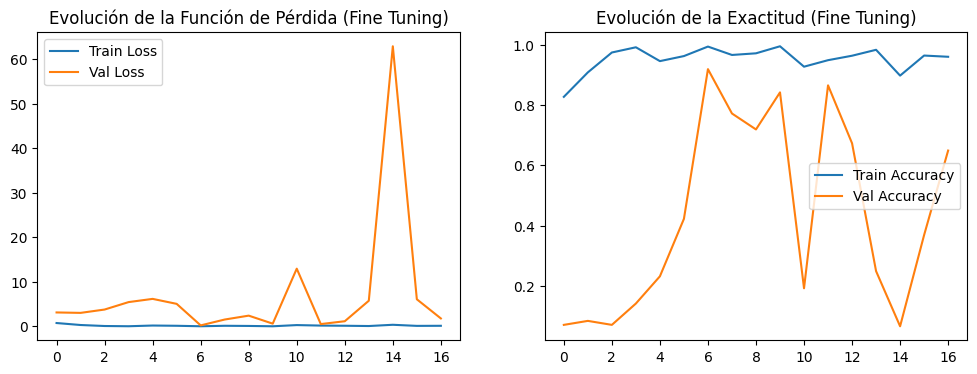

In [29]:
# Visualizamos la evolución
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_ft.history['loss'], label='Train Loss')
plt.plot(history_ft.history['val_loss'], label='Val Loss')
plt.title('Evolución de la Función de Pérdida (Fine Tuning)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ft.history['accuracy'], label='Train Accuracy')
plt.plot(history_ft.history['val_accuracy'], label='Val Accuracy')
plt.title('Evolución de la Exactitud (Fine Tuning)')
plt.legend()

plt.show()

### Ejercicio 12

Muestra la evaluación contra el test, el informe de clasificación  y la matriz de confusión. Compara los resultados con los del ejercicio 9.

Exactitud en Test (Fine Tuning desde cero): 79.52%

67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step
--- Classification Report (Fine Tuning) ---
              precision    recall  f1-score   support

    Braeburn       0.89      0.95      0.92       164
 CrimsonSnow       1.00      0.11      0.21       148
     Golden1       0.80      0.85      0.82       160
     Golden2       0.77      1.00      0.87       164
     Golden3       0.64      1.00      0.78       161
 GrannySmith       1.00      0.59      0.74       164
    PinkLady       0.53      1.00      0.69       152
        Red1       1.00      0.69      0.82       164
        Red2       0.93      0.96      0.95       164
        Red3       1.00      0.83      0.90       144
RedDelicious       1.00      0.25      0.40       166
  RedYellow1       1.00      1.00      1.00       164
  RedYellow2       0.70      1.00      0.82       219

    accuracy                           0.80      2134
   macro avg       0.87      0.79      0.76      213

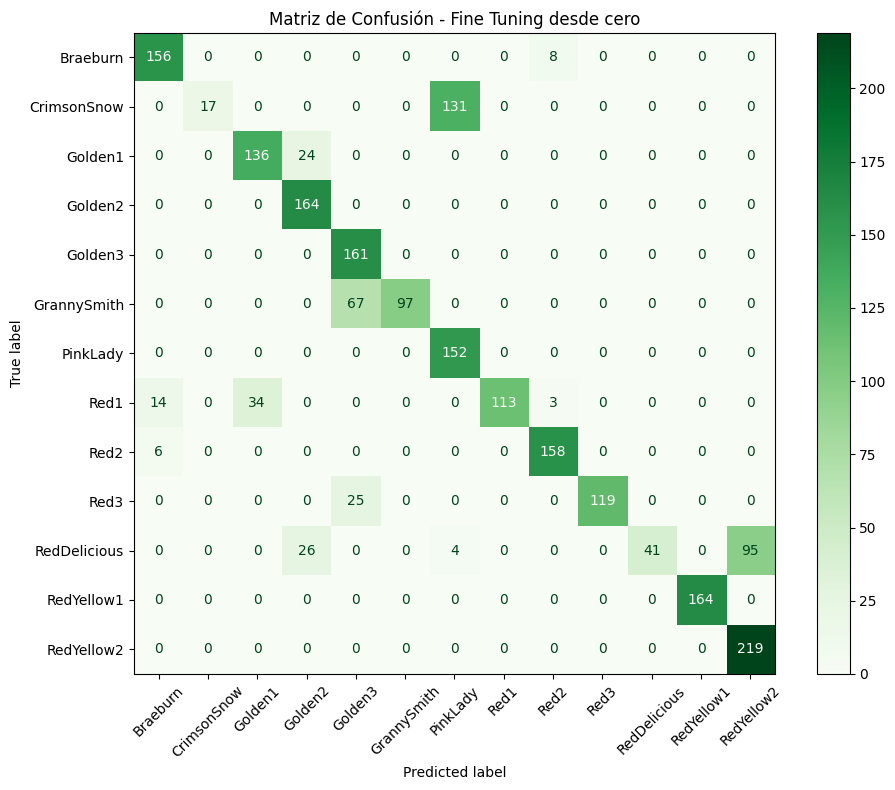

In [30]:
# Por último, evaluamos este modelo entrenado desde cero contra los datos de test, sacamos las métricas (informe y matriz) 
# y comparamos los resultados con los que obtuvimos en el ejercicio 9.

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Evaluamos el modelo contra test
loss_ft, accuracy_ft = modelo_ft.evaluate(X_test_norm, y_test_num, verbose=0)
print(f"Exactitud en Test (Fine Tuning desde cero): {accuracy_ft * 100:.2f}%\n")

# Predicciones
predicciones_prob_ft = modelo_ft.predict(X_test_norm)
predicciones_clases_ft = np.argmax(predicciones_prob_ft, axis=1)

# Reporte de clasificación
print("--- Classification Report (Fine Tuning) ---")
print(classification_report(y_test_num, predicciones_clases_ft, target_names=nombres_clases))

# Matriz de confusión
matriz_conf_ft = confusion_matrix(y_test_num, predicciones_clases_ft)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_conf_ft, display_labels=nombres_clases)
disp.plot(cmap=plt.cm.Greens, xticks_rotation=45, ax=plt.gca()) # Uso tonos verdes para distinguirla de la anterior
plt.title('Matriz de Confusión - Fine Tuning desde cero')
plt.tight_layout()
plt.show()